<a href="https://colab.research.google.com/github/srijitaaa2005/MY-WORKS-DEEP-LEARNING-/blob/main/cats_vs_dogs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srijitaaa18","key":"f0e2c6fabd2e5305a40b2dca5b3b84e7"}'}

In [2]:
!pip install -q kaggle

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [4]:
!kaggle datasets download -d pushpakhinglaspure/cats-vs-dogs

Dataset URL: https://www.kaggle.com/datasets/pushpakhinglaspure/cats-vs-dogs
License(s): DbCL-1.0
100% 546M/546M [00:31<00:00, 18.2MB/s]



In [5]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cats-vs-dogs.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [7]:
#generators
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/dogs_vs_cats/train',
    labels='inferred',
    label_mode='int', #cats=0, dogs=1
    batch_size=32,
    image_size=(256,256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dogs_vs_cats/dogs_vs_cats/test',
    labels='inferred',
    label_mode='int', #cats=0, dogs=1
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
#normalize
def process(image,label):
  image=tf.cast(image/255, tf.float32)
  return image, label
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

**DATA AUGMENTATION**

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size=16

train_datagen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen=ImageDataGenerator(rescale=1./256)

train_generator=train_datagen.flow_from_directory(
    '/content/dogs_vs_cats/dogs_vs_cats/train',
    target_size=(256,256),
    batch_size= batch_size,
    class_mode='binary'
)
validation_generator=test_datagen.flow_from_directory(
    '/content/dogs_vs_cats/dogs_vs_cats/test',
    target_size=(256,256),
    batch_size= batch_size,
    class_mode='binary'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [45]:
#cnn architechture
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [46]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

history=model.fit(
    train_generator,
    steps_per_epoch=2000 // batch_size,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=800 // batch_size)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 278ms/step - accuracy: 0.5425 - loss: 13.8446 - val_accuracy: 0.5300 - val_loss: 2.6570
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 260ms/step - accuracy: 0.5245 - loss: 5.0731 - val_accuracy: 0.5075 - val_loss: 1.9577
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 269ms/step - accuracy: 0.4990 - loss: 1.1920 - val_accuracy: 0.4700 - val_loss: 1.0619
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.4995 - loss: 0.7512 - val_accuracy: 0.4750 - val_loss: 0.8527
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 316ms/step - accuracy: 0.5190 - loss: 0.7059 - val_accuracy: 0.4863 - val_loss: 0.7173
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.4800 - loss: 0.7058 - val_accuracy: 0.4950 - val_loss: 0.6924
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 263ms/step - accuracy: 0.4905 - loss: 0.7148 - val_accuracy: 0.5387 - val_loss: 0.6849
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - accuracy: 0.5065 - loss: 

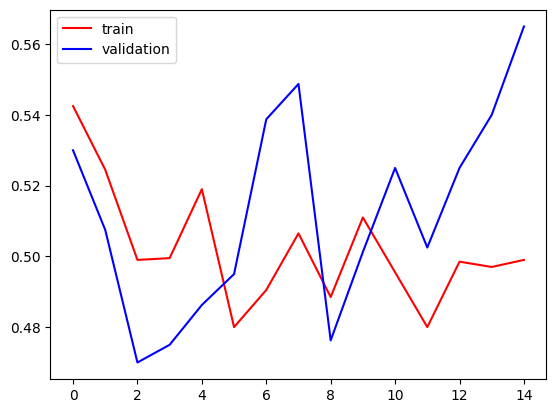

In [47]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

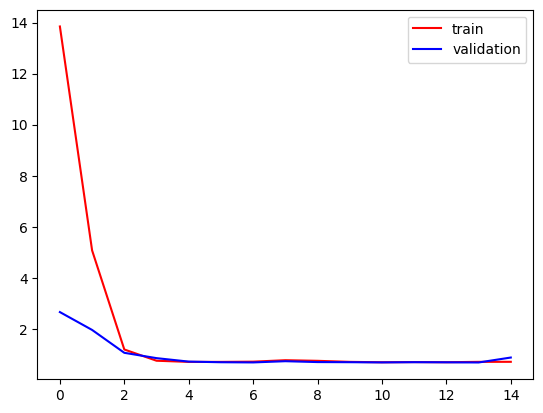

In [48]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [49]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.49900001287460327
Validation Accuracy: 0.5649999976158142


In [50]:
print(train_generator.class_indices)

{'cats': 0, 'dogs': 1}


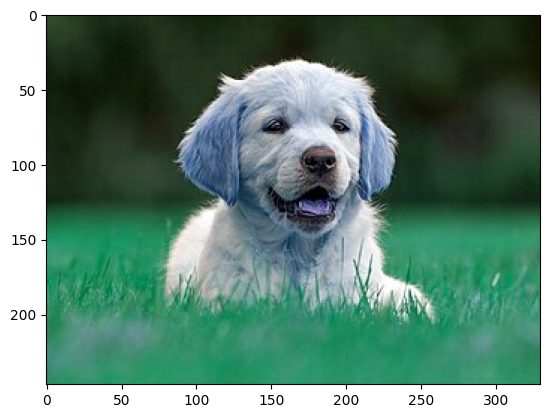

In [51]:
import cv2

test_img_dog=cv2.imread('/content/dog.jpg')
plt.imshow(test_img_dog)

In [52]:
test_img_dog=cv2.resize(test_img_dog,(256,256))
test_input_dog=test_img_dog.reshape((1,256,256,3))
model.predict(test_input_dog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step


array([[0.5011436]], dtype=float32)

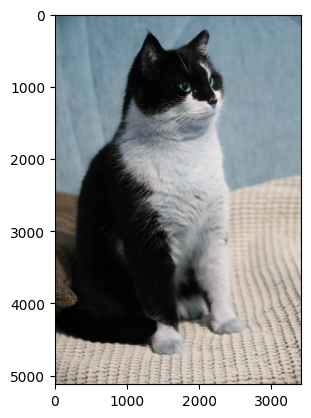

In [53]:
test_img_cat=cv2.imread('/content/cat.jpg')
plt.imshow(test_img_cat)

In [54]:
test_img_cat=cv2.resize(test_img_cat,(256,256))
test_input_cat=test_img_cat.reshape((1,256,256,3))
model.predict(test_input_cat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0.5011436]], dtype=float32)